### Video playback

In [1]:
## conda env: stereo_vision
import os
import cv2
import numpy as np
import pyzed.sl as sl
import matplotlib.pyplot as plt

In [ ]:
# load coordinates of keypoints
input_folder = "./stereo_videos/validation_test"
input_file_name = "43916681.npz"

keypoint_coords = np.load(os.path.join(input_folder, input_file_name))

In [ ]:
# load coordinates and labels of keypoints

input_folder = "./stereo_videos/validation_test"
input_file_name = "43916681.npz"

file_path = os.path.join(input_folder, input_file_name)
if file_path:
    data = np.load(os.path.join(input_folder, input_file_name), allow_pickle=True)
    keypoint_coords = data["pose_data"]
    kpt_labels = data["kpt_labels"]
    print(f"file:  {os.path.basename(file_path)}")
    print(f'keys:  {list(data.keys())}')
    print(f'shape: {data['pose_data'].shape}')

file:  43916681.npz
keys:  ['pose_data', 'kpt_labels']
shape: (3908, 26, 3)


In [7]:
for idx, kpt in enumerate(kpt_labels):
    print(idx, kpt)

0 nose
1 left_eye
2 right_eye
3 left_ear
4 right_ear
5 left_shoulder
6 right_shoulder
7 left_elbow
8 right_elbow
9 left_wrist
10 right_wrist
11 left_hip
12 right_hip
13 left_knee
14 right_knee
15 left_ankle
16 right_ankle
17 top_head
18 neck
19 mid_hip
20 left_big_toe
21 right_big_toe
22 left_small_toe
23 right_small_toe
24 left_heel
25 right_heel


In [5]:
file_path.replace(".npz",".svo2")

'./stereo_videos/validation_test\\43916681.svo2'

In [ ]:
#TODO: update ZED sdk, try it with latest models, methods 

keypoint_with_depth = []

# Create a ZED camera object
zed = sl.Camera()

# Set SVO path for playback
input_path = file_path.replace(".npz", ".svo2")


input_type = sl.InputType()
input_type.set_from_svo_file(input_path)  # Set init parameter to run from the .svo
init_parameters = sl.InitParameters(input_t=input_type, svo_real_time_mode=False)

init_parameters.depth_mode = sl.DEPTH_MODE.ULTRA
init_parameters.coordinate_units = sl.UNIT.METER  # CENTIMETER, METER, MILLIMETER

# TODO: see how own filtering does without this built in one
init_parameters.depth_stabilization = 75

# Open the ZED
err = zed.open(init_parameters)
framerate = zed.get_camera_information().camera_configuration.fps
resolution = zed.get_camera_information().camera_configuration.resolution

svo_depth = sl.Mat()
svo_image = sl.Mat()

frame_idx = 0

while frame_idx < len(keypoint_coords) - 1 and zed.grab() == sl.ERROR_CODE.SUCCESS:
    
    # current_keypoints = np.empty(shape=(3))
    current_keypoints = []

    # Get frame count
    frame_idx = zed.get_svo_position()

    # get color image and depth map
    zed.retrieve_measure(svo_depth, sl.MEASURE.DEPTH)
    zed.retrieve_image(svo_image, sl.VIEW.LEFT)
    img = svo_image.get_data()
    depth_map = svo_depth.get_data()
    depth_map = np.transpose(depth_map)

    # get coords for all keypoints within the current frame
    # note: x,y coords are in pixels, depth is in meters
    # TODO: also store confidence values for depth
    for kpt_idx, keypoint in enumerate(kpt_labels):
        x = keypoint_coords[frame_idx, kpt_idx, 0]
        y = keypoint_coords[frame_idx, kpt_idx, 1]
        depth = depth_map[int(x), int(y)]
        current_keypoints.append(np.array([x,y,depth]))

        cv2.circle(img, (int(x), int(y)), 5, (0, 0, 255), 3)
        
    current_keypoints = np.array(current_keypoints)
    keypoint_with_depth.append(current_keypoints)
    # print(current_keypoints.shape)

    ## show DEPTH
    # cv2.imshow("View", cv2.resize(depth_map,(800,600)))

    ## show frame
    cv2.imshow("vid", cv2.resize(img, (800, 600)))

    if cv2.waitKey(25) & 0xFF == ord("q"):
        break


cv2.destroyAllWindows()
zed.close()

keypoint_with_depth = np.array(keypoint_with_depth)
keypoint_with_depth.shape

(3908, 26, 3)

In [ ]:
# save keypoints along with depth 
# note: original confidence values (for x,y) are not stored during the process
out_filename = os.path.join(input_folder, input_file_name.replace(".npz","_depth.npz"))
with open(out_filename, 'w') as f:
    np.savez(out_filename, pose_data=keypoint_with_depth, kpt_labels=kpt_labels)

In [28]:
framerate, resolution.width, resolution.height

(60.0, 1920, 1200)

## Not sure why it works

In [19]:
cv2.circle(depth_map, (50,100),5,(0,0,0),3)
cv2.circle(depth_map, (50,100),10,(255,255,255),3)
cv2.circle(depth_map, (50,100),15,(0,0,0),3)
cv2.circle(depth_map, (left_ankle_x, left_ankle_y), 5, (0, 0, 255), 3)
cv2.circle(depth_map, (right_ankle_x, right_ankle_y), 5, (0, 255, 0), 3)
cv2.imshow('depth_map',cv2.resize(depth_map, (800,600)))
cv2.waitKey(0)
cv2.destroyAllWindows()

In [21]:
print(f'camera depth: {svo_depth.get_width(),svo_depth.get_height()}')
print(f'camera image: {svo_image.get_width(),svo_image.get_height()} (widht, height)')

print(f'{depth_map.shape}')
print(f'{img.size, img.shape}')

camera depth: (1920, 1200)
camera image: (1920, 1200) (widht, height)
(1200, 1920)
(9216000, (1200, 1920, 4))


In [53]:
small_img = cv2.resize(img,(int(img.shape[1]/2),int(img.shape[0]/2)))
cv2.imshow('test',small_img)
cv2.circle(small_img, (left_ankle_x, left_ankle_y), 5, (0, 0, 255), 3)
cv2.circle(small_img, (right_ankle_y, right_ankle_x), 5, (0, 255, 0), 3)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [4]:
d = np.transpose(depth_map)
d.shape

(1920, 1200)

In [18]:
print(left_ankle_x, left_ankle_y, right_ankle_x, right_ankle_y)
print(depth_map.shape[1], depth_map.shape[0])
print(img.shape[1], img.shape[0])

1035 851 1277 874
1920 1200
1920 1200


## Saving & plotting output

In [24]:
out_folder = "./saved_keypoint_depth"
out_file_name = f"{input_file_name.split(".avi")[0]}_ankle_depth_cm__utlra75.npy"
np.save(
    os.path.join(out_folder,out_file_name), zed_ankle_depths
)
print(out_file_name)

50cm_walk_1_SVGA120FPS_low_pos_ankle_depth_cm__utlra75.npy


In [4]:
out_folder = "./saved_keypoint_depth"
out_file_name = os.path.join(out_folder,"50cm_walk_1_HD120060FPS_low_pos_ankle_depth_cm__utlra75.npy")
zed_ankle_depths = np.load(out_file_name)
zed_ankle_depths.shape

(2638, 2)

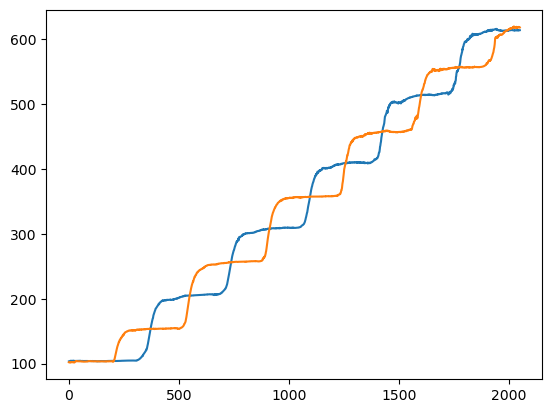

In [5]:
zed_ankle_depths = zed_ankle_depths[:2050]
plt.plot(zed_ankle_depths)

In [20]:
y = np.linspace(100,650,12)
y

array([100., 150., 200., 250., 300., 350., 400., 450., 500., 550., 600.,
       650.])

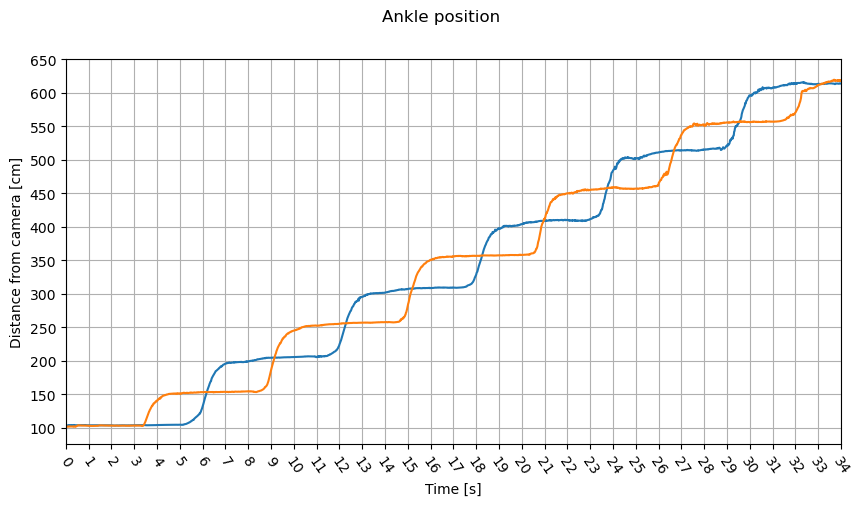

In [6]:
## time axis in seconds (instead of samples)
t = np.linspace(0,len(zed_ankle_depths)-1,len(zed_ankle_depths))/framerate

## plot ankle distances
plt.figure(figsize=(10,5))
plt.plot(t,zed_ankle_depths)
plt.suptitle("Ankle position")
# plt.title(out_file_name)
# plt.legend(['left ankle','right ankle'])
plt.xticks(np.linspace(0,np.floor(t[-1]),int(np.floor(t[-1]))+1))
plt.xticks(rotation=-55)
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Distance from camera [cm]")
plt.xlim([0,34])

plt.yticks(np.linspace(100,650,12))

# save the figure
# plt.savefig(os.path.join('./results',out_file_name.split('.npy')[0]+'_poster'+'.png'),format='svg',dpi=300)
plt.savefig('./Results/poster.svg', format='svg')